In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
data = '''
# nelec     rs    nkpts        HF           CCD_corr             AFQMC/HF                AFQMC/CID             AFQMC/CCD_PT
#    14      2.0     19      0.32254569  -0.220445612     0.098740 +/- 0.000562       0.097847 +/- 0.000211   0.098090 +/- 0.000140
    14      2.0     57      0.32254569  -0.357796417    -0.063925 +/- 0.000643      -0.061377 +/- 0.000390  -0.060828 +/- 0.000246
    14      2.0     93      0.32254569  -0.389438514    -0.098332 +/- 0.000571      -0.097270 +/- 0.000337  -0.097512 +/- 0.000354
    14      2.0     179     0.32254569  -0.401782863    -0.114193 +/- 0.000884      -0.111961 +/- 0.000619  -0.111861 +/- 0.000294
    14      2.0     257     0.32254569  -0.404580960    -0.116205 +/- 0.000632      -0.114621 +/- 0.000555  -0.114539 +/- 0.000320
    14      2.0     389     0.32254569  -0.406348882    -0.117379 +/- 0.000847      -0.117005 +/- 0.000547  -0.116953 +/- 0.000400
'''

In [3]:
m = np.array([])
hf = np.array([])
ccsd_corr = np.array([])
afqmc_hf = np.array([])
afqmc_ci = np.array([])
afqmc_pt = np.array([])
afqmc_hf_err = np.array([])
afqmc_ci_err = np.array([])
afqmc_pt_err = np.array([])
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        m = np.hstack((m,int(parts[2])))
        hf = np.hstack((hf,float(parts[3])))
        ccsd_corr = np.hstack((ccsd_corr,float(parts[4])))
        afqmc_hf = np.hstack((afqmc_hf,float(parts[5])))
        afqmc_hf_err = np.hstack((afqmc_hf_err,float(parts[7])))
        afqmc_ci = np.hstack((afqmc_ci,float(parts[8])))
        afqmc_ci_err = np.hstack((afqmc_ci_err,float(parts[10])))
        afqmc_pt = np.hstack((afqmc_pt,float(parts[11])))
        afqmc_pt_err = np.hstack((afqmc_pt_err,float(parts[13])))

afqmc_hf_corr = afqmc_hf - hf
afqmc_ci_corr = afqmc_ci - hf
afqmc_pt_corr = afqmc_pt - hf

inv_m = 1/m

In [4]:
def basis_ext(x,y,y_err=None):
    '''
    fitting Energy vs (num. of basis)^(-1)
    E(1/m) = a + b*(1/m)**2 + c*(1/m)**3
    '''
    A = np.column_stack([
        np.ones_like(x), 
        x**2, 
        x**3
        ])

    if y_err is not None:
        # weighted least squares
        W = np.diag(1 / y_err**2)
        cov = np.linalg.inv(A.T @ W @ A)
        (a,b,c) = cov @ (A.T @ W @ y)
        (da,db,dc) = np.sqrt(np.diag(cov))
    else:
        (a, b, c), residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)

        N = len(x)
        sigma2 = residuals[0] / (N - 3)      # variance of residuals
        cov = sigma2 * np.linalg.inv(A.T @ A)
        (da,db,dc) = np.sqrt(np.diag(cov))

    return (a,b,c), (da,db,dc)

In [5]:
(a1,b1,c1), (da1,db1,dc1) = basis_ext(inv_m,ccsd_corr,y_err=None)
(a2,b2,c2), (da2,db2,dc2) = basis_ext(inv_m,afqmc_hf_corr,y_err=afqmc_hf_err)
(a3,b3,c3), (da3,db3,dc3) = basis_ext(inv_m,afqmc_ci_corr,y_err=afqmc_ci_err)
(a4,b4,c4), (da4,db4,dc4) = basis_ext(inv_m,afqmc_pt_corr,y_err=afqmc_pt_err)
print(f'CCD extralopation = {a1:.5f} +/- {da1:.5f}')
print(f'AFQMC/HF extralopation = {a2:.3f} +/- {da2:.4f}')
print(f'AFQMC/CID extralopation = {a3:.3f} +/- {da3:.4f}')
print(f'AFQMC/CCD_PT extralopation = {a4:.3f} +/- {da4:.4f}')

CCD extralopation = -0.40689 +/- 0.00040
AFQMC/HF extralopation = -0.441 +/- 0.0006
AFQMC/CID extralopation = -0.440 +/- 0.0004
AFQMC/CCD_PT extralopation = -0.440 +/- 0.0003


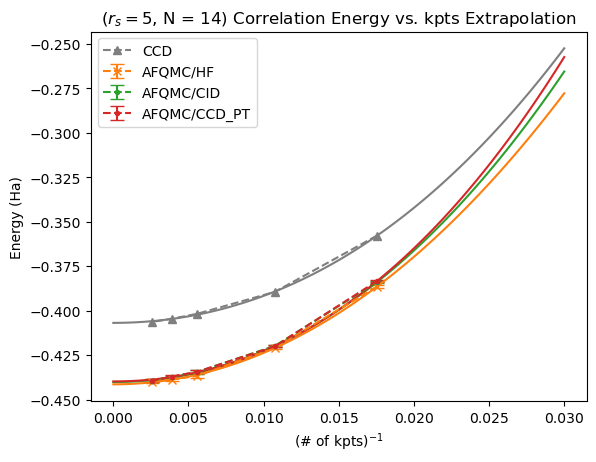

In [6]:
x = np.linspace(0,0.03,100)
y1 = a1 + b1*x**2 + c1*x**3
y2 = a2 + b2*x**2 + c2*x**3
y3 = a3 + b3*x**2 + c3*x**3
y4 = a4 + b4*x**2 + c4*x**3

plt.plot(inv_m,ccsd_corr,'^--',color='C7',label='CCD')
plt.errorbar(inv_m,afqmc_hf_corr,yerr=afqmc_hf_err,fmt='x--',capsize=5,color='C1',label='AFQMC/HF')
plt.errorbar(inv_m,afqmc_ci_corr,yerr=afqmc_hf_err,fmt='.--',capsize=5,color='C2',label='AFQMC/CID')
plt.errorbar(inv_m,afqmc_pt_corr,yerr=afqmc_hf_err,fmt='.--',capsize=5,color='C3',label='AFQMC/CCD_PT')
plt.plot(x,y1,'-',color='C7',label='CCD(fit)')
plt.plot(x,y2,'-',color='C1',label='AFQMC/HF(fit)')
plt.plot(x,y3,'-',color='C2',label='AFQMC/CID(fit)')
plt.plot(x,y4,'-',color='C3',label='AFQMC/CCD_PT(fit)')
plt.xlabel('(# of kpts)$^{-1}$')
plt.ylabel('Energy (Ha)')
plt.title('($r_s = 5$, N = 14) Correlation Energy vs. kpts Extrapolation')
handles, labels = plt.gca().get_legend_handles_labels()
order = ['CCD', 'AFQMC/HF', 'AFQMC/CID', 'AFQMC/CCD_PT']
ordered_handles = [handles[labels.index(l)] for l in order]
ordered_labels = order
plt.legend(ordered_handles, ordered_labels,loc='upper left')
plt.show()

In [7]:
def basis_ext_lin(x,y,y_err=None):
    '''
    fitting Energy vs (num. of basis)^(-1)
    E(1/m) = a + b*(1/m)
    '''
    A = np.column_stack([
        np.ones_like(x), 
        x
        ])

    if y_err is not None:
        # weighted least squares
        W = np.diag(1 / y_err**2)
        cov = np.linalg.inv(A.T @ W @ A)
        (a,b) = cov @ (A.T @ W @ y)
        (da,db) = np.sqrt(np.diag(cov))
    else:
        (a, b), residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)

        N = len(x)
        sigma2 = residuals[0] / (N - 2)      # variance of residuals
        cov = sigma2 * np.linalg.inv(A.T @ A)
        (da,db) = np.sqrt(np.diag(cov))

    return (a,b), (da,db)

In [8]:
(a1,b1), (da1,db1) = basis_ext_lin(inv_m[-3:],ccsd_corr[-3:],y_err=None)
(a2,b2), (da2,db2) = basis_ext_lin(inv_m[-3:],afqmc_hf_corr[-3:],y_err=afqmc_hf_err[-3:])
(a3,b3), (da3,db3) = basis_ext_lin(inv_m[-3:],afqmc_ci_corr[-3:],y_err=afqmc_ci_err[-3:])
(a4,b4), (da4,db4) = basis_ext_lin(inv_m[-3:],afqmc_pt_corr[-3:],y_err=afqmc_pt_err[-3:])
print(f'CCD extralopation = {a1:.4f} +/- {da1:.4f}')
print(f'AFQMC/HF extralopation = {a2:.3f} +/- {da2:.3f}')
print(f'AFQMC/CID extralopation = {a3:.3f} +/- {da3:.3f}')
print(f'AFQMC/CCD_PT extralopation = {a4:.3f} +/- {da4:.3f}')

CCD extralopation = -0.4103 +/- 0.0004
AFQMC/HF extralopation = -0.443 +/- 0.002
AFQMC/CID extralopation = -0.444 +/- 0.001
AFQMC/CCD_PT extralopation = -0.444 +/- 0.001


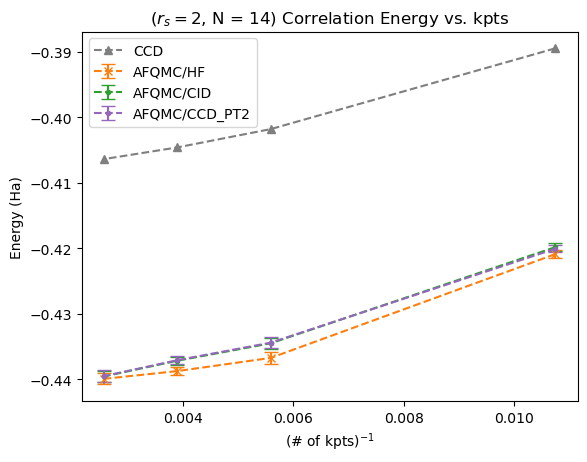

In [9]:
x = np.linspace(0,0.016,100)
y1 = a1 + b1*x
y2 = a2 + b2*x
y3 = a3 + b3*x
y4 = a4 + b4*x

plt.plot(inv_m[1:],ccsd_corr[1:],'^--',color='C7',label='CCD')
plt.errorbar(inv_m[1:],afqmc_hf_corr[1:],yerr=afqmc_hf_err[1:],fmt='x--',capsize=5,color='C1',label='AFQMC/HF')
plt.errorbar(inv_m[1:],afqmc_ci_corr[1:],yerr=afqmc_hf_err[1:],fmt='.--',capsize=5,color='C2',label='AFQMC/CID')
plt.errorbar(inv_m[1:],afqmc_pt_corr[1:],yerr=afqmc_hf_err[1:],fmt='.--',capsize=5,color='C4',label='AFQMC/CCD_PT2')
# plt.plot(x,y1,'-',color='C7',label='CCD(fit)')
# plt.plot(x,y2,'-',color='C1',label='AFQMC/HF(fit)')
# plt.plot(x,y3,'-',color='C2',label='AFQMC/CID(fit)')
# plt.plot(x,y4,'-',color='C3',label='AFQMC/CCD_PT(fit)')
plt.xlabel('(# of kpts)$^{-1}$')
plt.ylabel('Energy (Ha)')
plt.title('($r_s = 2$, N = 14) Correlation Energy vs. kpts')
handles, labels = plt.gca().get_legend_handles_labels()
order = ['CCD', 'AFQMC/HF', 'AFQMC/CID', 'AFQMC/CCD_PT2']
ordered_handles = [handles[labels.index(l)] for l in order]
ordered_labels = order
plt.legend(ordered_handles, ordered_labels,loc='upper left')
plt.show()